In [1]:
from pathlib import Path

ROOT = Path.cwd().parent

DATASETS = [
    ROOT / "dataset_1",
    ROOT / "dataset_2",
    ROOT / "dataset_3"
]

print("Project folder:", ROOT)
print("-" * 50)

for dataset in DATASETS:
    print(dataset.name, "->", "FOUND ✅" if dataset.exists() else "NOT FOUND ❌")

Project folder: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT
--------------------------------------------------
dataset_1 -> FOUND ✅
dataset_2 -> FOUND ✅
dataset_3 -> FOUND ✅


In [4]:

from pathlib import Path
from PIL import Image

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def check_images(dataset_path):
    image_files = [
        p for p in dataset_path.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ]

    corrupted = []
    zero_size = []

    for image_path in image_files:
        try:
            if image_path.stat().st_size == 0:
                zero_size.append(str(image_path))
                continue

            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted.append(str(image_path))

    print(f"\nDataset: {dataset_path.name}")
    print("Total images:", len(image_files))
    print("Corrupted images:", len(corrupted))
    print("Zero-size images:", len(zero_size))
    print("Corrupted examples:", corrupted[:5])
    print("Zero-size examples:", zero_size[:5])

for dataset_path in DATASETS:
    check_images(dataset_path)


Dataset: dataset_1
Total images: 6724
Corrupted images: 0
Zero-size images: 0
Corrupted examples: []
Zero-size examples: []

Dataset: dataset_2
Total images: 1254
Corrupted images: 0
Zero-size images: 0
Corrupted examples: []
Zero-size examples: []

Dataset: dataset_3
Total images: 146
Corrupted images: 0
Zero-size images: 0
Corrupted examples: []
Zero-size examples: []


In [3]:
%pip install pillow

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.2 MB 3.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/7.2 MB 2.5 MB/s eta 0:00:03
   -------- ------------------------------- 1.6/7.2 MB 2.8 MB/s eta 0:00:03
   ------------- -------------------------- 2.4/7.2 MB 3.1 MB/s eta 0:00:02
   ------------------ --------------------- 3.4/7.2 MB 3.5 MB/s eta 0:00:02
   ----------------------- ---------------- 4.2/7.2 MB 3.6 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 6.3/7.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 3.4 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 3.4 MB/s eta 0:00:01
   ----------------

In [5]:

from pathlib import Path

def validate_yolo_labels(dataset_name, num_classes):
    dataset_path = ROOT / dataset_name
    label_files = list((dataset_path / "labels").rglob("*.txt"))

    if not label_files:
        label_files = list(dataset_path.rglob("labels/**/*.txt"))

    invalid_files = []
    total_boxes = 0
    empty_files = 0

    for label_file in label_files:
        try:
            lines = label_file.read_text(encoding="utf-8").splitlines()

            if not lines:
                empty_files += 1
                continue

            for line_number, line in enumerate(lines, start=1):
                parts = line.split()

                if len(parts) != 5:
                    invalid_files.append(
                        (str(label_file), line_number, "Expected 5 values")
                    )
                    continue

                try:
                    class_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:])
                except ValueError:
                    invalid_files.append(
                        (str(label_file), line_number, "Non-numeric value")
                    )
                    continue

                if not (0 <= class_id < num_classes):
                    invalid_files.append(
                        (str(label_file), line_number, "Invalid class ID")
                    )
                    continue

                if not all(map(lambda v: 0 <= v <= 1, [x, y, w, h])):
                    invalid_files.append(
                        (str(label_file), line_number, "Coordinates out of range")
                    )
                    continue

                if w <= 0 or h <= 0:
                    invalid_files.append(
                        (str(label_file), line_number, "Invalid box dimensions")
                    )
                    continue

                total_boxes += 1

        except (OSError, UnicodeError) as error:
            invalid_files.append((str(label_file), 0, str(error)))

    print(f"\nDataset: {dataset_name}")
    print("Label files:", len(label_files))
    print("Valid bounding boxes:", total_boxes)
    print("Empty label files:", empty_files)
    print("Invalid annotations:", len(invalid_files))
    print("Examples:", invalid_files[:5])


validate_yolo_labels("dataset_1", 23)
validate_yolo_labels("dataset_2", 5)
validate_yolo_labels("dataset_3", 3)


Dataset: dataset_1
Label files: 6724
Valid bounding boxes: 7464
Empty label files: 0
Invalid annotations: 0
Examples: []

Dataset: dataset_2
Label files: 1254
Valid bounding boxes: 2388
Empty label files: 0
Invalid annotations: 0
Examples: []

Dataset: dataset_3
Label files: 146
Valid bounding boxes: 621
Empty label files: 0
Invalid annotations: 0
Examples: []



dataset_1 — Class Distribution
0: person = 187
1: car = 372
2: truck = 367
3: bus = 295
4: motorcycle = 107
5: red light = 475
6: green light = 490
7: stop sign = 415
8: no entry = 229
9: no overtaking = 209
10: speed limit 20 = 387
11: speed limit 30 = 434
12: speed limit 40 = 343
13: speed limit 50 = 404
14: speed limit 60 = 421
15: speed limit 70 = 431
16: speed limit 80 = 417
17: speed limit 100 = 365
18: speed limit 120 = 356
19: no left turn = 183
20: no right turn = 179
21: no stopping = 333
22: no u-turn = 65


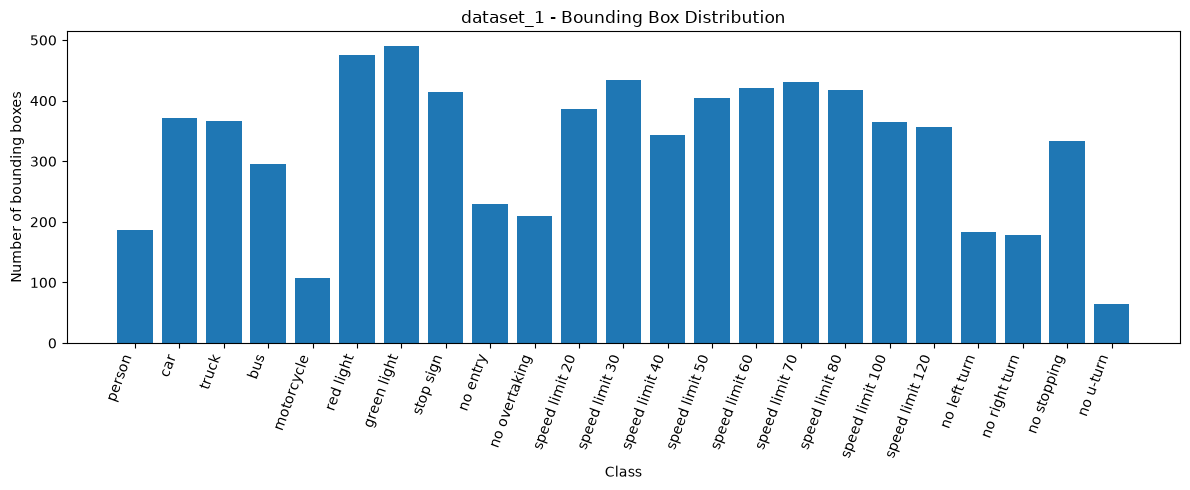


dataset_2 — Class Distribution
0: Ambulance = 0
1: Bus = 0
2: Car = 0
3: Motorcycle = 0
4: Truck = 0


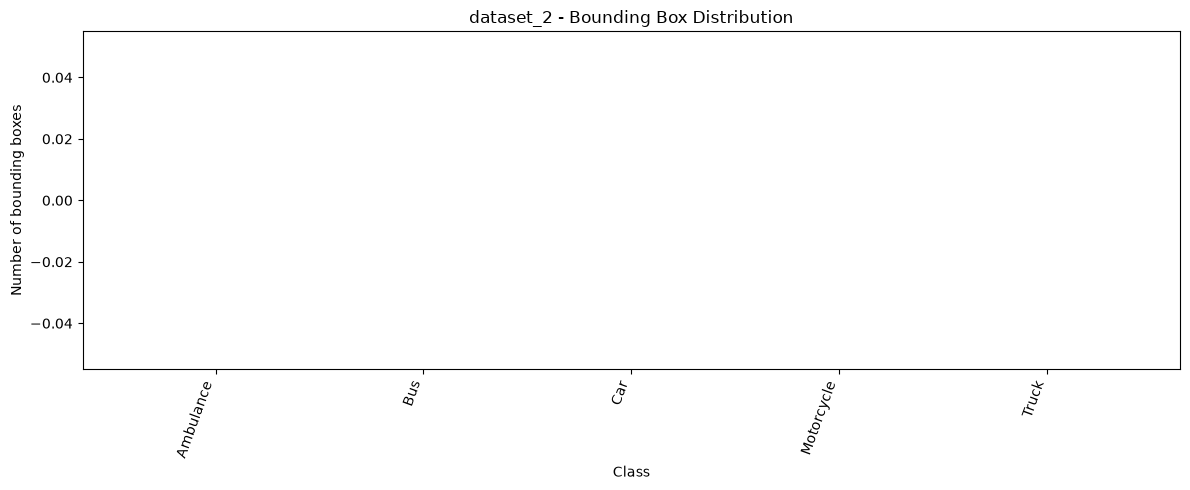


dataset_3 — Class Distribution
0: bike = 0
1: helmet = 0
2: no helmet = 0


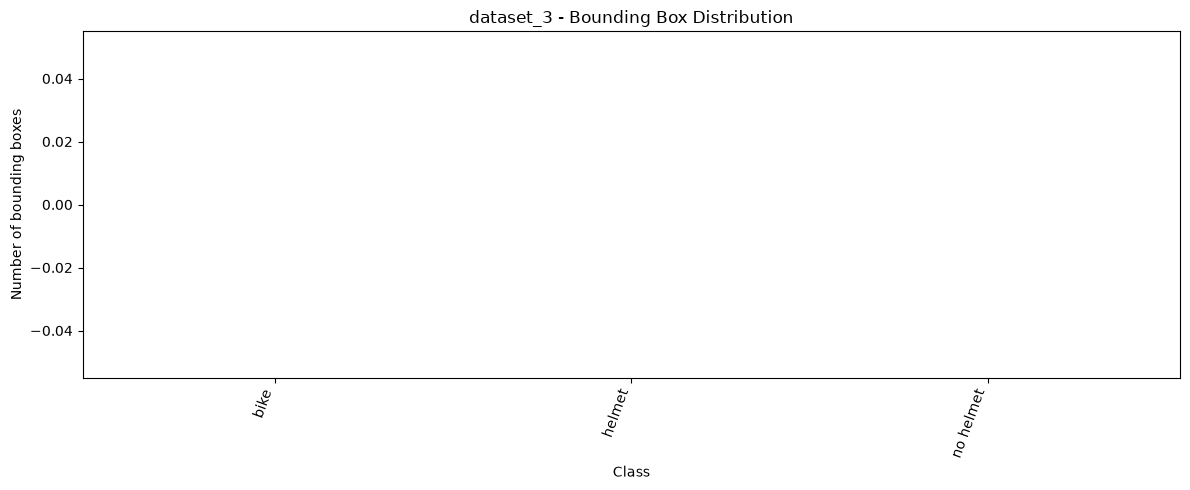

In [10]:

from collections import Counter
from pathlib import Path
import yaml
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_name):
    dataset_path = ROOT / dataset_name

    with open(dataset_path / "data.yaml", "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    names = config["names"]
    if isinstance(names, list):
        class_names = {i: name for i, name in enumerate(names)}
    else:
        class_names = {int(k): v for k, v in names.items()}

    counts = Counter()

    for label_file in (dataset_path / "labels").rglob("*.txt"):
        for line in label_file.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) == 5:
                counts[int(parts[0])] += 1

    print(f"\n{dataset_name} — Class Distribution")
    for class_id, name in class_names.items():
        print(f"{class_id}: {name} = {counts[class_id]}")

    labels = [
        class_names[class_id]
        for class_id in class_names
    ]
    values = [counts[class_id] for class_id in class_names]

    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)
    plt.title(f"{dataset_name} - Bounding Box Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of bounding boxes")
    plt.xticks(rotation=70, ha="right")
    plt.tight_layout()
    plt.show()

for name in ["dataset_1", "dataset_2", "dataset_3"]:
    plot_class_distribution(name)

In [8]:
%pip install matplotlib

  Using cached matplotlib-3.11.2-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.1-cp311-cp311-win_amd64.whl.metadata (132 kB)
  Using cached kiwisolver-1.5.1-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\BHOOMIKA\\anaconda3\\envs\\tensorflow\\Lib\\site-packages\\numpy\\_core\\tests\\test_errstate.py'
Consider using the `--user` option or check the permissions.



  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------------------------

In [9]:

import matplotlib.pyplot as plt
print("Matplotlib installed successfully!")

Matplotlib installed successfully!


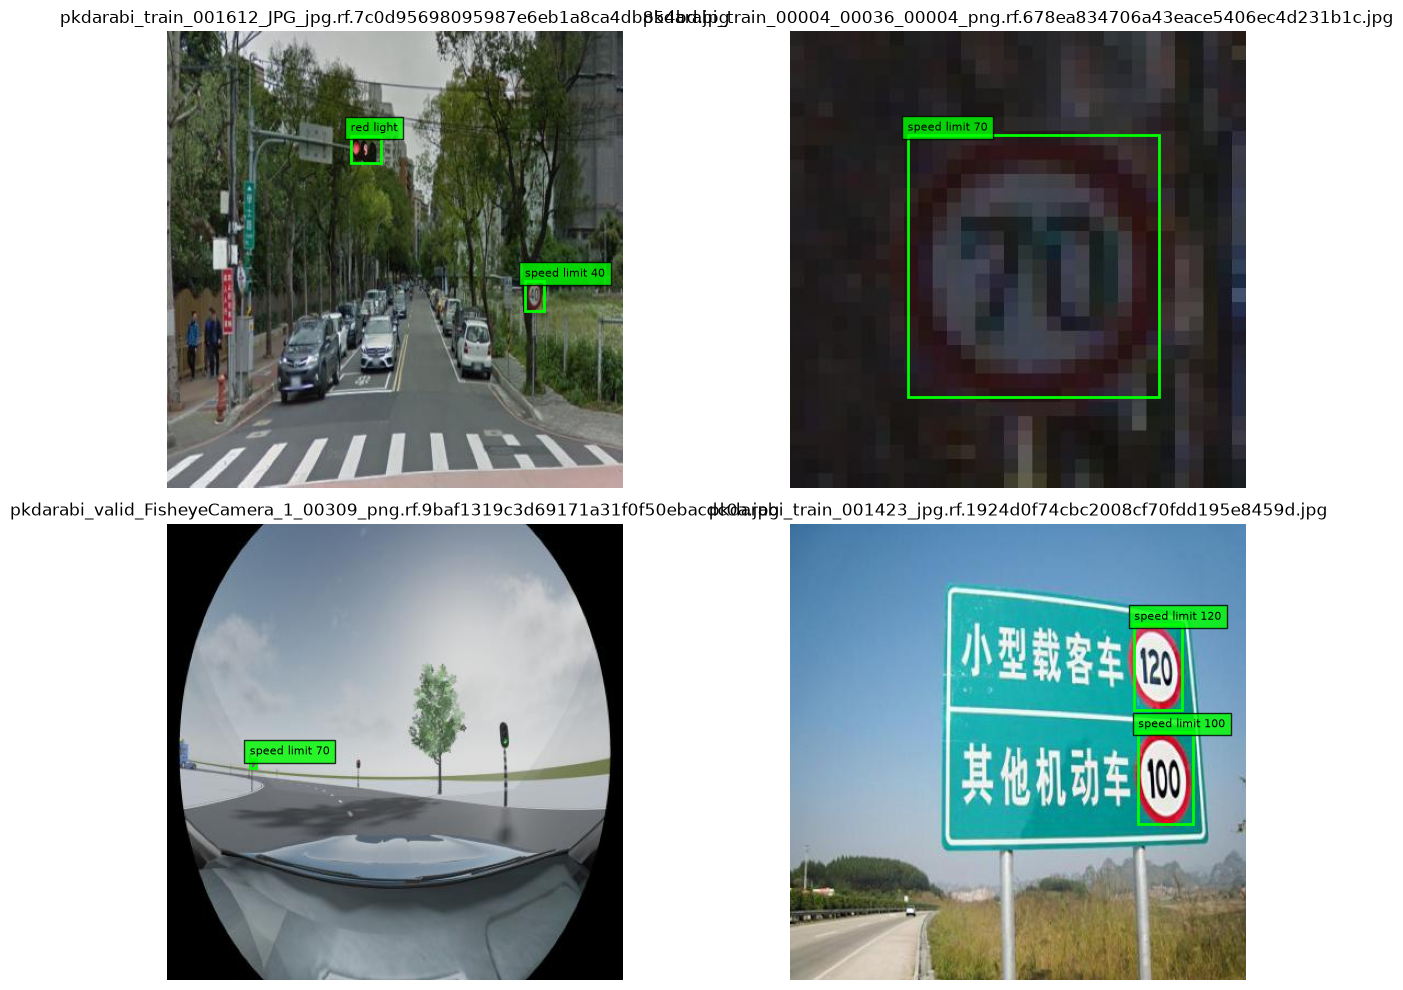

In [11]:

import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml

dataset_path = ROOT / "dataset_1"

with open(dataset_path / "data.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

names = config["names"]
if isinstance(names, list):
    class_names = names
else:
    class_names = {int(k): v for k, v in names.items()}

image_files = [
    p for p in (dataset_path / "images").rglob("*")
    if p.is_file() and p.suffix.lower() in
    {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

selected_images = random.sample(image_files, min(4, len(image_files)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, image_path in zip(axes, selected_images):
    label_path = (
        dataset_path / "labels" /
        image_path.parent.name /
        f"{image_path.stem}.txt"
    )

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")

    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            x1 = (x - w / 2) * width
            y1 = (y - h / 2) * height
            box_width = w * width
            box_height = h * height

            rect = patches.Rectangle(
                (x1, y1), box_width, box_height,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)

            name = class_names[class_id]
            ax.text(
                x1, max(0, y1 - 4), name,
                color="black", fontsize=8,
                bbox=dict(facecolor="lime", alpha=0.8)
            )

plt.tight_layout()
plt.show()

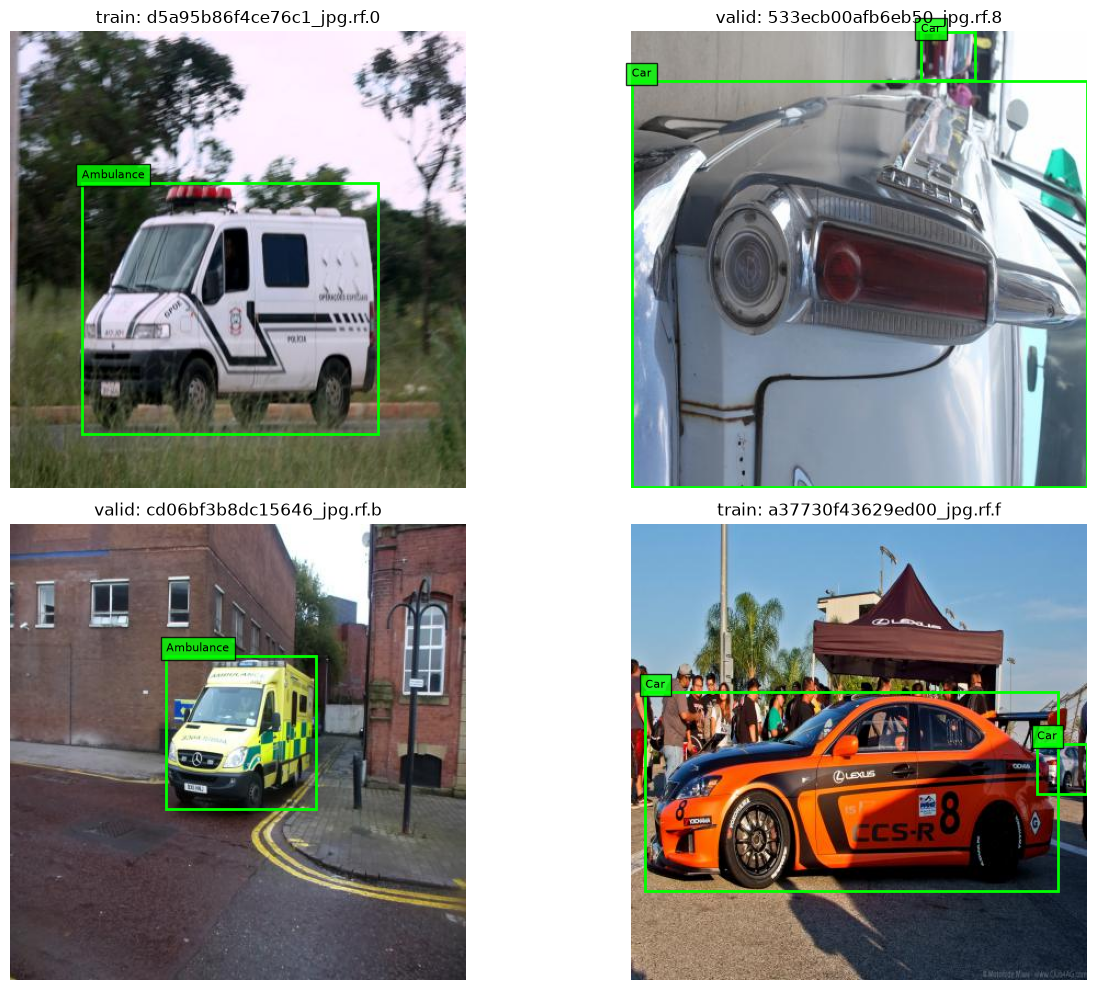

In [12]:

import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml

dataset_path = ROOT / "dataset_2"

with open(dataset_path / "data.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

names = config["names"]
if isinstance(names, list):
    class_names = names
else:
    class_names = {int(k): v for k, v in names.items()}

# Dataset 2 structure: train/images, valid/images, test/images
image_files = [
    p for split in ["train", "valid", "test"]
    for p in (dataset_path / split / "images").rglob("*")
    if p.is_file() and p.suffix.lower() in
    {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

selected_images = random.sample(image_files, min(4, len(image_files)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, image_path in zip(axes.flatten(), selected_images):
    # Matching labels are in the same split's labels folder
    split = image_path.parent.parent.name
    label_path = dataset_path / split / "labels" / f"{image_path.stem}.txt"

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    ax.imshow(image)
    ax.set_title(f"{split}: {image_path.name[:25]}")
    ax.axis("off")

    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            x1 = (x - w / 2) * width
            y1 = (y - h / 2) * height

            rect = patches.Rectangle(
                (x1, y1), w * width, h * height,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(0, y1 - 4), class_names[class_id],
                color="black", fontsize=8,
                bbox=dict(facecolor="lime", alpha=0.8)
            )
    else:
        ax.set_title("LABEL NOT FOUND")

plt.tight_layout()
plt.show()

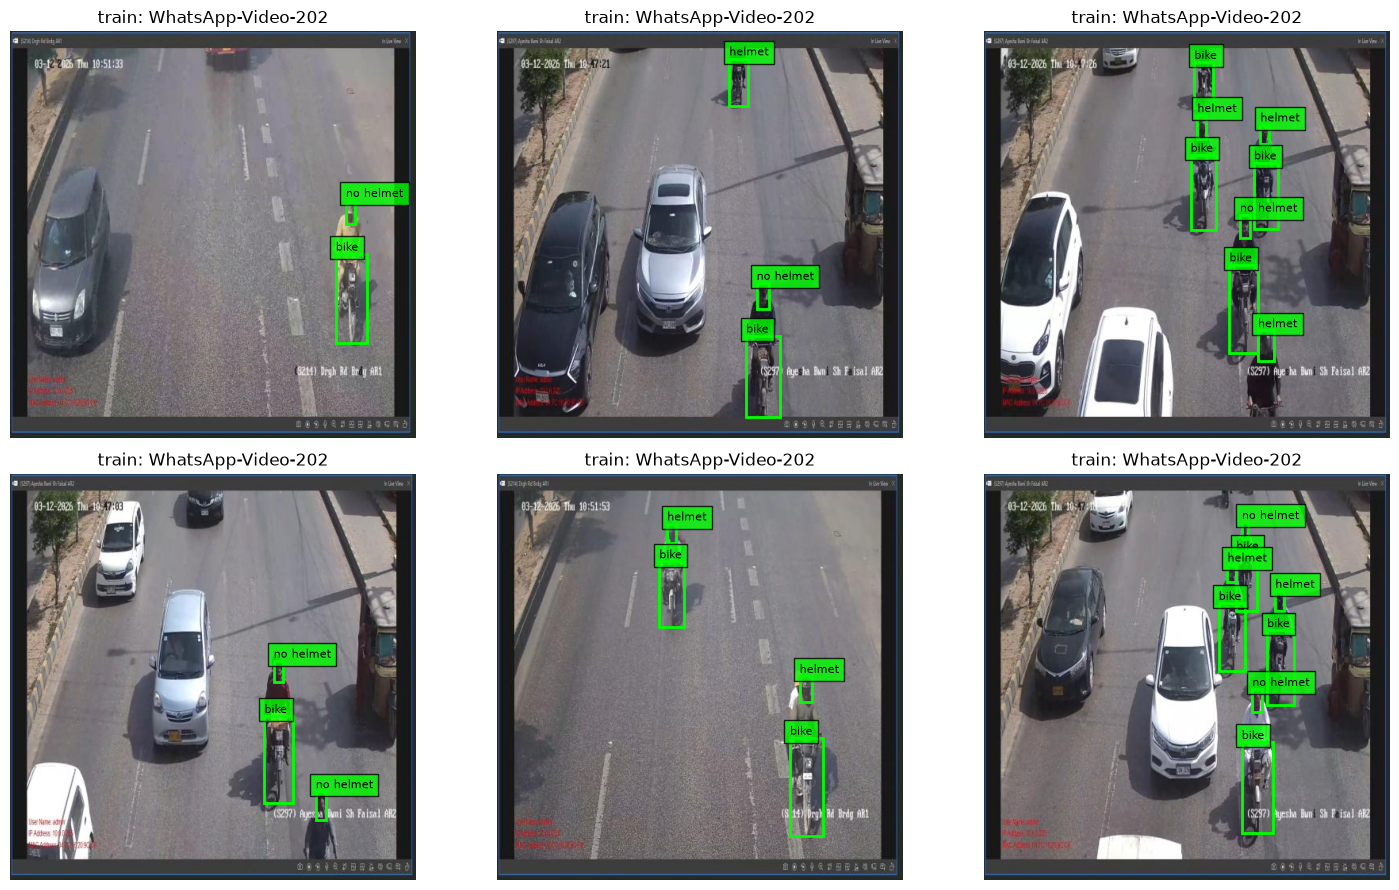

In [13]:

import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml

dataset_path = ROOT / "dataset_3"

with open(dataset_path / "data.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

names = config["names"]
if isinstance(names, list):
    class_names = names
else:
    class_names = {int(k): v for k, v in names.items()}

image_files = [
    p for split in ["train", "valid", "test"]
    for p in (dataset_path / split / "images").rglob("*")
    if p.is_file() and p.suffix.lower() in
    {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

selected_images = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, image_path in zip(axes.flatten(), selected_images):
    split = image_path.parent.parent.name
    label_path = dataset_path / split / "labels" / f"{image_path.stem}.txt"

    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    ax.imshow(image)
    ax.set_title(f"{split}: {image_path.name[:18]}")
    ax.axis("off")

    if label_path.exists():
        for line in label_path.read_text(encoding="utf-8").splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue

            class_id = int(parts[0])
            x, y, w, h = map(float, parts[1:])

            x1 = (x - w / 2) * width
            y1 = (y - h / 2) * height

            rect = patches.Rectangle(
                (x1, y1), w * width, h * height,
                linewidth=2, edgecolor="lime", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(0, y1 - 4), class_names[class_id],
                color="black", fontsize=8,
                bbox=dict(facecolor="lime", alpha=0.8)
            )

plt.tight_layout()
plt.show()

In [14]:

from pathlib import Path
import yaml

PREPARED_DIR = ROOT / "prepared_data"
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

dataset_settings = {
    "dataset_1": {
        "train": "images/train",
        "val": "images/val",
    },
    "dataset_2": {
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
    },
    "dataset_3": {
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
    },
}

for dataset_name, settings in dataset_settings.items():
    dataset_path = ROOT / dataset_name
    original_yaml = dataset_path / "data.yaml"

    with open(original_yaml, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    # Use the correct local dataset directory
    config["path"] = dataset_path.as_posix()

    # Set the correct image paths for each split
    config.update(settings)

    output_yaml = PREPARED_DIR / f"{dataset_name}.yaml"

    with open(output_yaml, "w", encoding="utf-8") as f:
        yaml.safe_dump(
            config,
            f,
            sort_keys=False,
            allow_unicode=True
        )

    print(f"\n{dataset_name}:")
    print("Config created:", output_yaml)
    print("Train images:", config["train"])
    print("Validation images:", config["val"])
    print("Classes:", config["nc"])

print("\nAll dataset configurations prepared!")


dataset_1:
Config created: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_1.yaml
Train images: images/train
Validation images: images/val
Classes: 23

dataset_2:
Config created: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_2.yaml
Train images: train/images
Validation images: valid/images
Classes: 5

dataset_3:
Config created: c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_3.yaml
Train images: train/images
Validation images: valid/images
Classes: 3

All dataset configurations prepared!


In [15]:

from pathlib import Path
import yaml

PREPARED_DIR = ROOT / "prepared_data"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for dataset_name in ["dataset_1", "dataset_2", "dataset_3"]:
    yaml_path = PREPARED_DIR / f"{dataset_name}.yaml"

    with open(yaml_path, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    dataset_root = Path(config["path"])

    print(f"\n{'=' * 45}")
    print("Dataset:", dataset_name)
    print("YAML exists:", yaml_path.exists())

    for split in ["train", "val", "test"]:
        if split not in config:
            continue

        image_dir = dataset_root / config[split]
        exists = image_dir.is_dir()

        count = sum(
            1 for p in image_dir.rglob("*")
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ) if exists else 0

        print(f"{split}: {exists} | Images: {count}")

    print("Number of classes:", config["nc"])
    print("Class names:", config["names"])

print("\nPath verification complete!")


Dataset: dataset_1
YAML exists: True
train: True | Images: 5254
val: True | Images: 1470
Number of classes: 23
Class names: {0: 'person', 1: 'car', 2: 'truck', 3: 'bus', 4: 'motorcycle', 5: 'red light', 6: 'green light', 7: 'stop sign', 8: 'no entry', 9: 'no overtaking', 10: 'speed limit 20', 11: 'speed limit 30', 12: 'speed limit 40', 13: 'speed limit 50', 14: 'speed limit 60', 15: 'speed limit 70', 16: 'speed limit 80', 17: 'speed limit 100', 18: 'speed limit 120', 19: 'no left turn', 20: 'no right turn', 21: 'no stopping', 22: 'no u-turn'}

Dataset: dataset_2
YAML exists: True
train: True | Images: 878
val: True | Images: 250
test: True | Images: 126
Number of classes: 5
Class names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']

Dataset: dataset_3
YAML exists: True
train: True | Images: 102
val: True | Images: 30
test: True | Images: 14
Number of classes: 3
Class names: ['bike', 'helmet', 'no helmet']

Path verification complete!


In [16]:
%pip install ultralytics

  Using cached ultralytics-8.4.173-py3-none-any.whl.metadata (46 kB)
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached torch-2.14.1-cp311-cp311-win_amd64.whl.metadata (38 kB)
  Using cached polars-1.44.2-py3-none-any.whl.metadata (11 kB)
  Using cached nvidia_ml_py-13.615.71-py3-none-any.whl.metadata (9.7 kB)
  Using cached ultralytics_thop-2.2.2-py3-none-any.whl.metadata (14 kB)
  Using cached ultralytics_platform-0.1.80-py3-none-any.whl.metadata (16 kB)
  Using cached polars_runtime_32-1.44.2-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
  Using cached charset_normalizer-3.5.2-cp311-cp311-win_amd64.whl.metadata (47 kB)
  Using cached idna-3.20-py3-none-any.whl.metadata (7.2 kB)
  Using cached urllib3-2.8.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached filelock-4.0.12-py3-none-any.whl.metadata (2.0 kB)
  Usin

In [17]:

from ultralytics import YOLO
from pathlib import Path

yaml_path = ROOT / "prepared_data" / "dataset_1.yaml"

model = YOLO("yolo11n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=5,
    imgsz=640,
    batch=8,
    workers=0,
    patience=5,
    project=str(ROOT / "runs"),
    name="traffic_detection_5epochs",
    exist_ok=True
)

print("Training completed!")
print("Best model:", ROOT / "runs" / "traffic_detection_5epochs" / "weights" / "best.pt")

Ultralytics 8.4.173  Python-3.11.17 torch-2.14.1+cpu CPU (13th Gen Intel Core i5-1334U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\prepared_data\dataset_1.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tr

In [18]:
from ultralytics import YOLO
from pathlib import Path
import random

model_path = (
    ROOT / "runs" / "traffic_detection_5epochs"
    / "weights" / "best.pt"
)

model = YOLO(str(model_path))

image_folder = ROOT / "dataset_1" / "images" / "val"

images = [
    p for p in image_folder.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

test_image = random.choice(images)

results = model.predict(
    source=str(test_image),
    conf=0.25,
    save=True
)

print("Model testing completed!")
print("Test image:", test_image.name)


image 1/1 c:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\dataset_1\images\val\bdd_extra_4_28.jpg: 384x640 1 car, 88.5ms
Speed: 2.1ms preprocess, 88.5ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to C:\Users\BHOOMIKA\OneDrive\Documents\Desktop\AICW PROJECT\NEW FLODER\runs\detect\predict
Model testing completed!
Test image: bdd_extra_4_28.jpg
